# 🌸 Flower Classification using VGG16 Transfer Learning

## 📌 Project Overview
This project builds an image classification system that identifies **5 types of flowers** — Daisy, Sunflower, Tulip, Dandelion, and Rose — using **Transfer Learning with VGG16** architecture built on TensorFlow and Keras.

## 🎯 Objective
To classify flower images into 5 categories using a pretrained VGG16 model with custom fully connected layers, achieving high accuracy with limited training data.

## 📦 Dataset
- **Source** : TensorFlow Flower Photos (auto-downloaded)
- **Total Images** : ~3,670
- **Classes** : Daisy | Sunflower | Tulip | Dandelion | Rose

## 🏗️ Approach
- Images loaded with **OpenCV**, resized to 150×150 and normalized
- **Data Augmentation** applied (rotation, zoom, flips, shifts)
- **VGG16** used as frozen base feature extractor
- Custom **Dense(256) + Dense(5, Softmax)** layers added on top
- Trained for **50 epochs** with Adam optimizer (lr=1e-4)
- **ReduceLROnPlateau** callback used for learning rate scheduling

## 📊 Result
- ✅ Test Accuracy : **~81%**

## 🛠️ Tech Stack
`TensorFlow` `Keras` `VGG16` `OpenCV` `NumPy` `Matplotlib` `Scikit-learn`

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [2]:
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

import cv2       # open CV
import os
import tensorflow as tf
import keras
# Data manipulation & visulation
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# data augmentation - import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#model creation and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, classification_report
from sklearn.preprocessing import LabelEncoder

from keras.layers import Dense
from keras.layers import Flatten, Activation
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import Adam, RMSprop, SGD
# import to_categorical
from keras.utils import to_categorical
from keras.models import Sequential
from keras.applications.vgg16 import VGG16
from keras.callbacks import ReduceLROnPlateau


import random as rn
from tqdm import tqdm

In [3]:
# We will download flowers dataset from google website and store it locally. In below call it downloads the zip file (.tgz) in cache_dir which is . meaning the current folder

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(origin=dataset_url, fname="flower_photos", untar=True, cache_dir=".")
# untar=True means that it will extract the contents of the downloaded file and store it in the specified cache_dir. In this case, it will extract the contents of the downloaded file and store it in the current folder (.) under a directory named "flower_photos". The get_file function will return the path to the extracted directory, which is assigned to the variable data_dir.
# cache_dir is the directory where the downloaded file will be stored. In this case, it is set to ".", which means the current directory. The downloaded file will be saved in the current directory before being extracted.
data_dir

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


'./datasets/flower_photos'

In [4]:
data_dir = data_dir + "/flower_photos"
data_dir

'./datasets/flower_photos/flower_photos'

In [5]:
print(os.listdir(data_dir))
# count = 0
# for root, folders, filenames in os.walk('/kaggle/input'):
#    print(root, folders)

['tulips', 'sunflowers', 'LICENSE.txt', 'daisy', 'dandelion', 'roses']


In [6]:
Daisy_flower_dir = data_dir + '/daisy'
Sunflower_flower_dir = data_dir + '/sunflowers'
Tulip_flower_dir = data_dir + '/tulips'
Dandelion_flower_dir = data_dir + '/dandelion'
Rose_flower_dir = data_dir + '/roses'

In [7]:
images = []
labels = []
img_size = 150

def image_data(flower_name, DIR):
    for i in tqdm(os.listdir(DIR)):
        try:

            path = os.path.join(DIR,i)
            img = cv2.imread(path)
            img = cv2.resize(img, (img_size, img_size))
            img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

            images.append(np.array(img))
            labels.append(str(flower_name))

        except:
            print(path)


In [8]:
image_data('Daisy', Daisy_flower_dir)
len(images)

100%|██████████| 633/633 [00:00<00:00, 747.02it/s]


633

In [9]:
image_data('Sunflowers', Sunflower_flower_dir)
len(images)

100%|██████████| 699/699 [00:01<00:00, 597.17it/s]


1332

In [10]:
image_data('Tulip', Tulip_flower_dir)
len(images)

100%|██████████| 799/799 [00:01<00:00, 678.88it/s]


2131

In [11]:
image_data('Dandelion', Dandelion_flower_dir)
len(images)

100%|██████████| 898/898 [00:01<00:00, 770.19it/s]


3029

In [12]:
image_data('Rose', Rose_flower_dir)
len(images)

100%|██████████| 641/641 [00:00<00:00, 706.74it/s]


3670

In [13]:
633+699+799+898+641

3670

In [14]:
data = np.array(images)
labels = np.array(labels)
print('Input(Feature) Data shape :', data.shape)
print('Output(Labels) Data shape :', labels.shape)

Input(Feature) Data shape : (3670, 150, 150, 3)
Output(Labels) Data shape : (3670,)


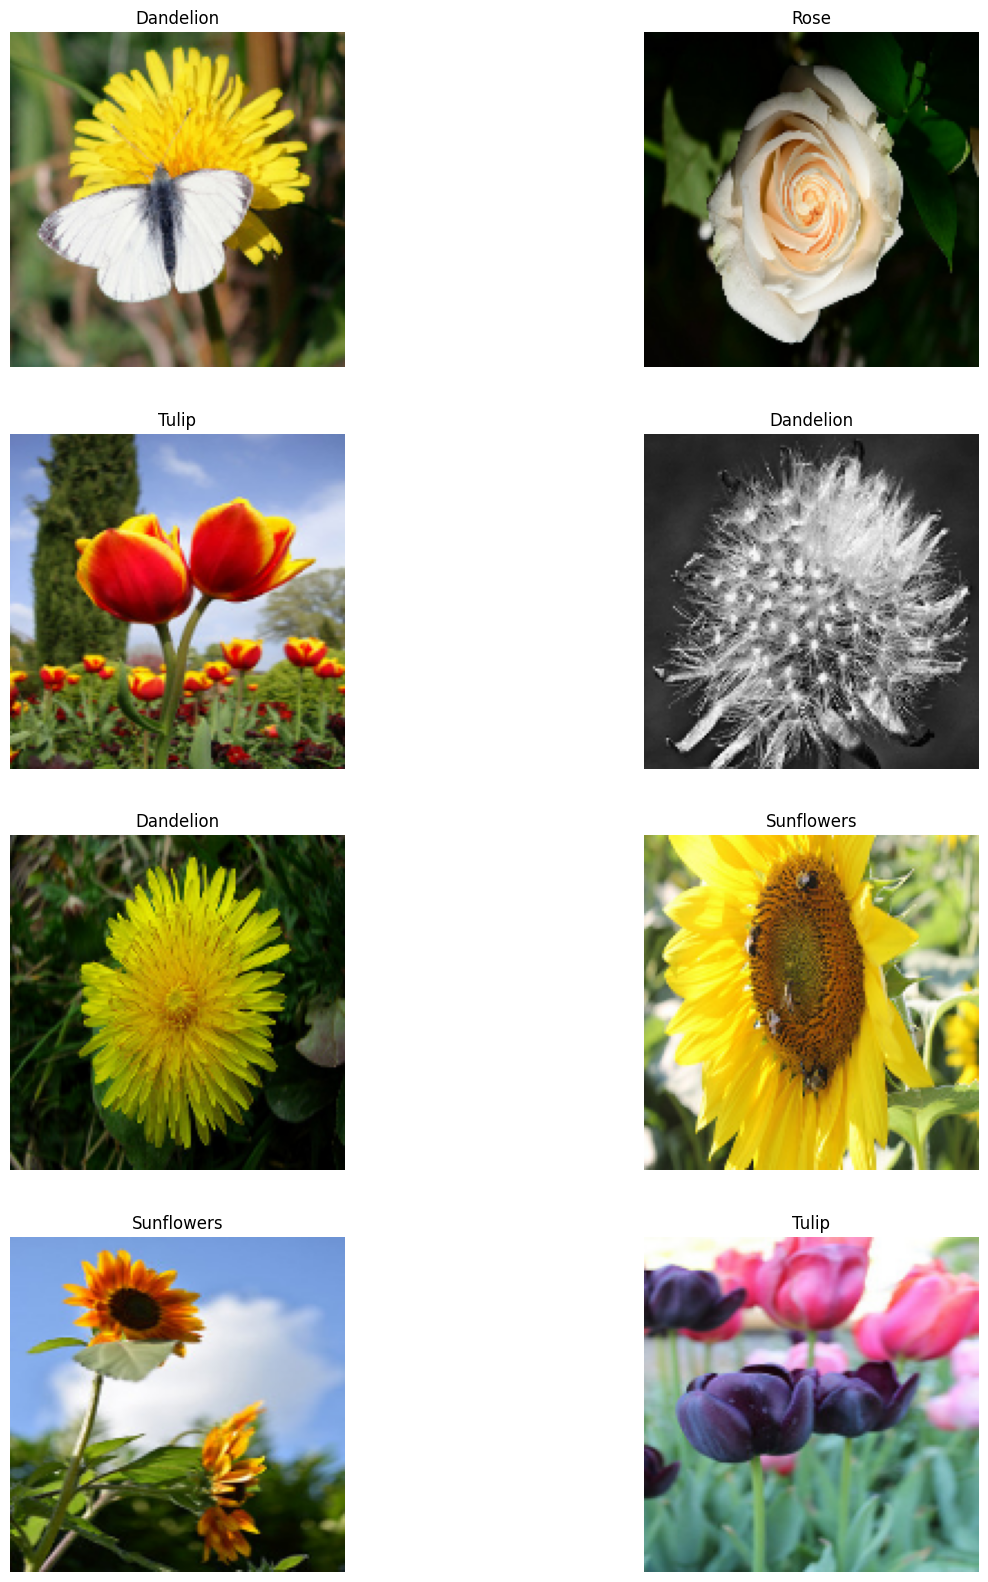

In [15]:
fig, ax = plt.subplots(4, 2, figsize = (15, 20))
for i in range(4):
    for j in range(2):
        l = rn.randint(0, data.shape[0])
        ax[i,j].imshow(data[l])
        ax[i,j].set_title(labels[l])
        ax[i,j].axis('off')

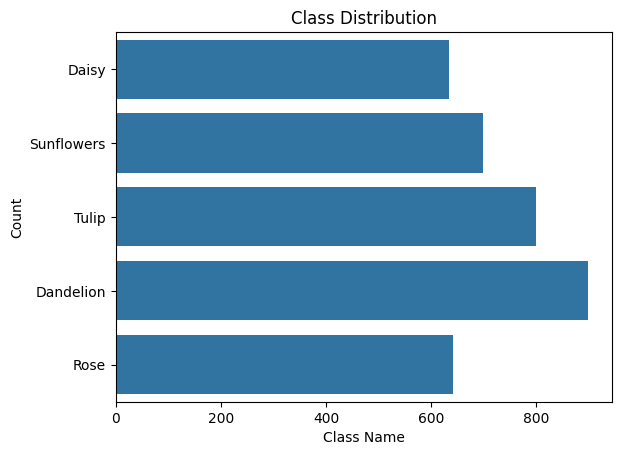

In [16]:
sns.countplot(labels)
plt.title("Class Distribution")
plt.xlabel("Class Name")
plt.ylabel("Count")
plt.show()

In [17]:
le = LabelEncoder()
y = le.fit_transform(labels)
y = to_categorical(y, 5)
y[0]

array([1., 0., 0., 0., 0.])

In [18]:
# Normalize the input data in range [0 1]
X = data/255

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 5)

print("X_train shape :",X_train.shape)
print("y_train shape :",y_train.shape)
print("X_test shape :" ,X_test.shape)
print("y_test shape :",y_test.shape)

X_train shape : (2936, 150, 150, 3)
y_train shape : (2936, 5)
X_test shape : (734, 150, 150, 3)
y_test shape : (734, 5)


In [20]:
from keras.layers import Dense
from keras.layers import Flatten, Activation
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import Adam, RMSprop, SGD
from keras.models import Sequential
from tensorflow.keras.applications.vgg16 import VGG16
from keras.callbacks import ReduceLROnPlateau

In [21]:
Base_model = VGG16(include_top= False,
                   weights='imagenet',
                   input_shape=(150,150,3),
                   pooling='avg')
Base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

- We are not using fully connected layers of VGG16 model(include_top= False).
- We will add it from our side because in VGG16 softmax layer has 1000 classes and We have only 5 classes.
- We are using pretrained weights of Imagenet
- This is a sumary of my base model not a actual model

## Add Fully Connected Layers

In [22]:
model = Sequential()

model.add(Base_model)
model.add(Dense(256,activation='relu'))
# adding prediction(softmax) layer
model.add(Dense(5,activation="softmax"))

In [23]:
# freeze layers that are already pre-trained(Base Model)
Base_model.trainable = False

Setting a learning rate annealer
To make the optimizer converge faster and closest to the global minimum of the loss function, an annealing method of the learning rate (LR) needs to be used.

In [24]:
reduc_lr=ReduceLROnPlateau(monitor='val_acc', factor=0.1, min_delta=0.0001, patience=2, verbose=1)

In [25]:
# Data augmentation
datagen = ImageDataGenerator(featurewise_center= False,
                              samplewise_center= False,
                              featurewise_std_normalization= False,
                              samplewise_std_normalization=False,
                              rotation_range= 10,        # 0- 180
                              zca_whitening=False,
                              zoom_range=0.1,            # Randomly zoom image
                              width_shift_range=0.2,     # randomly shift images horizontally (fraction of total width)
                              height_shift_range=0.2,    # randomly shift images vertically (fraction of total height)
                              horizontal_flip=True,      # randomly flip images
                              vertical_flip=False)       # randomly flip images

datagen.fit(X_train)

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [27]:
# Compiling and Training the Model
model.compile(optimizer=Adam(learning_rate= 1e-4), loss= 'categorical_crossentropy', metrics=['accuracy'])

In [28]:
# This took 63 minutes to execute on my Macbook M3 Pro
batch_size=64
model_history = model.fit(datagen.flow(X_train,y_train, batch_size=batch_size),
                              epochs = 50, validation_data = (X_test,y_test),
                              verbose = 1, steps_per_epoch=X_train.shape[0] // batch_size)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.3276 - loss: 1.5613 - val_accuracy: 0.3706 - val_loss: 1.4710
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.2969 - loss: 1.5145 - val_accuracy: 0.3651 - val_loss: 1.4680
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 478ms/step - accuracy: 0.4774 - loss: 1.4083 - val_accuracy: 0.5681 - val_loss: 1.3233
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6250 - loss: 1.2632 - val_accuracy: 0.5668 - val_loss: 1.3201
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 478ms/step - accuracy: 0.5850 - loss: 1.2803 - val_accuracy: 0.6458 - val_loss: 1.1943
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.5625 - loss: 1.2287 - val_accuracy: 0.6390 - val_loss: 1.1915
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 482ms/step - accuracy: 0.6250 - loss: 1.1678 - val_accuracy: 0.6785 - val_loss: 1.0900
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6250 - loss: 1.1403 - val_accuracy: 0.679

In [29]:
model.save('model.keras')

In [30]:
from tensorflow.keras.models import load_model

In [31]:
model1 = load_model('model.keras')

In [32]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,112,529 (57.65 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 265,228 (1.01 MB)

In [33]:
model.evaluate(X_test,y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.7875 - loss: 0.6288


[0.6288354992866516, 0.7874659299850464]

## model test accuracy is 81%

In [34]:
y_pred = model1.predict(X_train)

92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step


In [35]:
X_train.shape

(2936, 150, 150, 3)

In [36]:
y_pred

array([[8.8679299e-02, 2.4575001e-02, 5.6820223e-03, 8.6466908e-01,
        1.6394520e-02],
       [8.7963641e-02, 2.7662894e-01, 1.2768708e-01, 4.2997733e-01,
        7.7743031e-02],
       [1.5129831e-02, 3.5758710e-03, 7.2231996e-01, 9.0740316e-02,
        1.6823401e-01],
       ...,
       [9.1771791e-03, 1.0661721e-03, 1.3515383e-01, 4.8104655e-03,
        8.4979236e-01],
       [8.1635071e-03, 9.8951459e-01, 2.3353031e-04, 1.8884036e-03,
        1.9996444e-04],
       [4.4647511e-02, 9.3448663e-01, 9.5321769e-03, 6.2176147e-03,
        5.1160096e-03]], dtype=float32)